C:\anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 7995 images belonging to 5 classes.
Found 1997 images belonging to 5 classes.
✅ Dataset Loaded Successfully
📊 Classes: ['Accident_Detection', 'Danger_road', 'Driver_Detection', 'Driver_drowsiness', 'Road']
📥 Training samples: 7995
📤 Validation samples: 1997
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8439 - loss: 0.4536 - precision: 0.8665 - recall: 0.8268  
Epoch 1: val_accuracy improved from None to 0.96645, saving model to models/best_model_initial.keras

Epoch 1: finished saving model to models/best_model_initial.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.9082 - loss: 0.2672 - precision: 0.9185 - recall: 0.9011 - val_accuracy: 0.9664 - val_loss: 0.1011 - val_precision: 0.9693 - val_recall: 0.9639 - learning_rate: 0.0010
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9478 - loss: 0.1677 - precision: 0.9517 - recall: 0.9442  
Epoch 2: val_accuracy improved from 0.96645 to 0.98798, saving model to models/best_model_initia

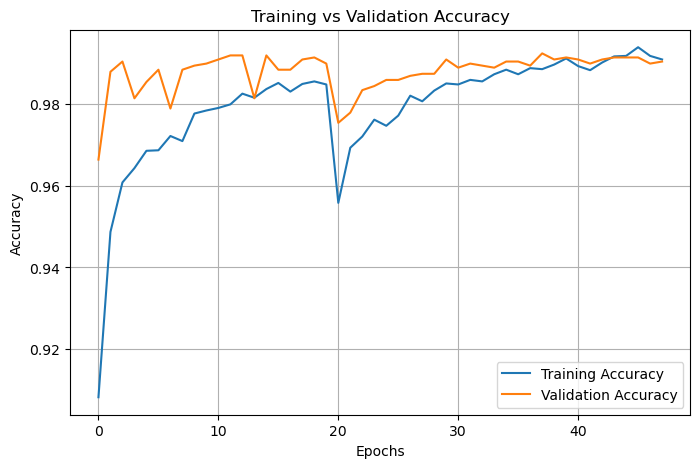

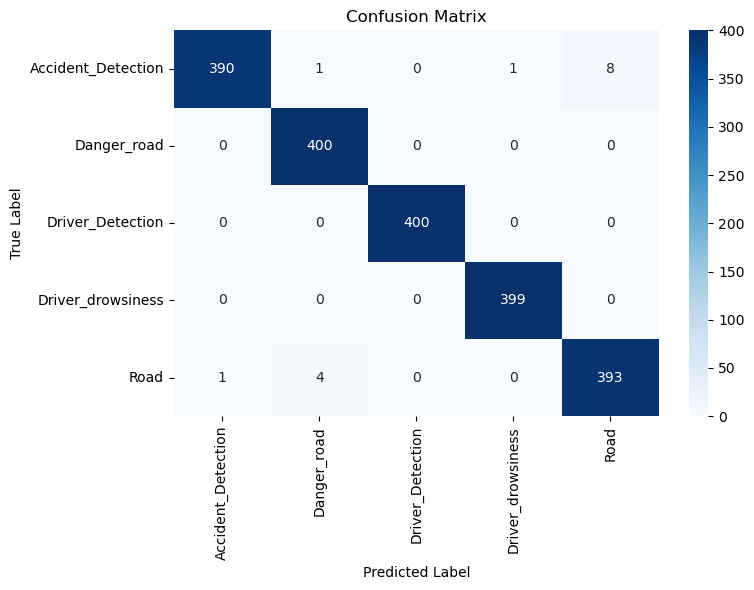


📊 Classification Report
                    precision    recall  f1-score   support

Accident_Detection       1.00      0.97      0.99       400
       Danger_road       0.99      1.00      0.99       400
  Driver_Detection       1.00      1.00      1.00       400
 Driver_drowsiness       1.00      1.00      1.00       399
              Road       0.98      0.99      0.98       398

          accuracy                           0.99      1997
         macro avg       0.99      0.99      0.99      1997
      weighted avg       0.99      0.99      0.99      1997




✅ TRAINING COMPLETED SUCCESSFULLY
🏆 Best Validation Accuracy: 99.25%


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ================= CONFIGURATION =================
DATASET_PATH = r"D:\dataset\vechile_blackbox_MODEL"  # your dataset path
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 20
FINE_TUNE_EPOCHS = 30
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# ================= DATA GENERATORS =================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
class_names = list(train_data.class_indices.keys())

print("✅ Dataset Loaded Successfully")
print("📊 Classes:", class_names)
print("📥 Training samples:", train_data.samples)
print("📤 Validation samples:", val_data.samples)

# ================= MODEL BUILD =================
def build_model(num_classes):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    return model, base_model

model, base_model = build_model(NUM_CLASSES)

# ================= CALLBACKS =================
callbacks_initial = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "models/best_model_initial.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    TensorBoard(log_dir=f"logs/{datetime.now().strftime('%Y%m%d-%H%M%S')}")
]

# ================= PHASE 1: INITIAL TRAINING =================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

initial_history = model.fit(
    train_data,
    epochs=INITIAL_EPOCHS,
    validation_data=val_data,
    callbacks=callbacks_initial,
    verbose=1
)

# ================= PHASE 2: FINE TUNING =================
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_finetune = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "models/best_model_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    TensorBoard(log_dir=f"logs/{datetime.now().strftime('%Y%m%d-%H%M%S')}_finetune")
]

fine_tune_history = model.fit(
    train_data,
    initial_epoch=INITIAL_EPOCHS,
    epochs=TOTAL_EPOCHS,
    validation_data=val_data,
    callbacks=callbacks_finetune,
    verbose=1
)

# ================= COMBINE HISTORY =================
def combine_histories(h1, h2):
    combined = {}
    keys = set(h1.history.keys()).union(set(h2.history.keys()))
    for key in keys:
        combined[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return combined

history = combine_histories(initial_history, fine_tune_history)

# ================= PLOT ACCURACY =================
plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.savefig("training_accuracy.png", dpi=100)
plt.show()

# ================= CONFUSION MATRIX =================
val_data.reset()
preds = model.predict(val_data, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

print("\n📊 Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

# ================= SAVE MODEL =================
model.save("vehicle_mobilenet_final.keras")
model.save("vehicle_mobilenet_final.h5")

with open("class_indices.json", "w") as f:
    json.dump(train_data.class_indices, f, indent=4)

print("\n✅ TRAINING COMPLETED SUCCESSFULLY")
print(f"🏆 Best Validation Accuracy: {max(history['val_accuracy']) * 100:.2f}%") 

In [3]:
best_train_acc = max(history["accuracy"])
best_val_acc = max(history["val_accuracy"])

print("\n🏆 BEST ACCURACY DURING TRAINING")
print(f"📈 Best Training Accuracy   : {best_train_acc * 100:.2f}%")
print(f"📉 Best Validation Accuracy : {best_val_acc * 100:.2f}%")



🏆 BEST ACCURACY DURING TRAINING
📈 Best Training Accuracy   : 99.40%
📉 Best Validation Accuracy : 99.25%


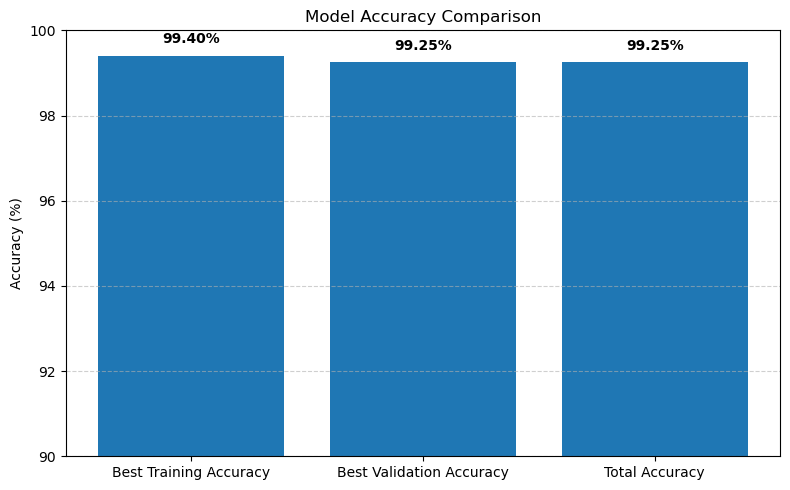

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ===== CALCULATE ACCURACIES =====
best_train_acc = max(history["accuracy"]) * 100
best_val_acc = max(history["val_accuracy"]) * 100

# total accuracy from confusion matrix
total_correct = np.trace(cm)
total_samples = np.sum(cm)
total_acc = (total_correct / total_samples) * 100

# ===== DATA =====
labels = ["Best Training Accuracy", "Best Validation Accuracy", "Total Accuracy"]
values = [best_train_acc, best_val_acc, total_acc]

# ===== BAR GRAPH =====
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.ylim(90, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

# ===== VALUE LABELS =====
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
